# Accuracy, Fairness, and Carbon Cost
### Auditing Machine Learning Models on Loan and Income Data

A reproducible walkthrough of the study. Every table and figure below is read
from `results/*.csv` and `figures/*.png`: the notebook retrains nothing and
hard-codes no result.

| | |
|---|---|
| **Datasets** | Adult (Census income, OpenML `adult` v2) and German Credit (OpenML `credit-g` v1) |
| **Audit attribute** | `sex` on Adult, `age >= 25` on German Credit - kept out of the features, kept for scoring |
| **Models** | logistic regression, random forest, XGBoost, MLP |
| **Protocol** | stratified 70/30 split fixed with seed 42; model seeds 0-4 |
| **Measurements** | accuracy / F1 / ROC-AUC, fairlearn fairness metrics, mitigation before-after, CO2eq from codecarbon |

Reproduce the whole study in one command:

```bash
python run_all.py
```

In [1]:
# Project imports: src/ holds the pipeline, the repository root holds run_all.
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":          # kernel started inside notebooks/
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT), str(ROOT / "src")]

import pandas as pd
from IPython.display import Image, display

from check_env import check_env
from data import DATASETS, SMALL_SAMPLE_WARNING
from train import DATA_SEED, SEEDS

RESULTS, FIGURES = ROOT / "results", ROOT / "figures"
pd.set_option("display.max_columns", 60)

print("kernel  :", sys.executable)
print("project :", ROOT)
print("seeds   :", SEEDS, "| split seed:", DATA_SEED)
print("datasets:", list(DATASETS))

kernel  : C:\Users\ahmad\Projects\loan-income-audit\.venv\Scripts\python.exe
project : C:\Users\ahmad\Projects\loan-income-audit
seeds   : [0, 1, 2, 3, 4] | split seed: 42
datasets: ['adult', 'german_credit']


In [2]:
# Loud by design: a missing package fails the notebook instead of hiding numbers.
assert check_env() == 0, "missing packages -> pip install -r requirements.txt"

Python 3.13.7 on Windows-11-10.0.22000-SP0
------------------------------------------------------------
pandas          3.0.6
numpy           2.5.3
scikit-learn    1.9.1
xgboost         3.4.1
fairlearn       0.14.0


shap            0.52.0
codecarbon      3.3.1
matplotlib      3.11.2
seaborn         0.13.2
jupyter         1.1.1
------------------------------------------------------------
All required packages are installed.


In [3]:
# The stages this notebook reports on, in the order run_all.py executes them.
import run_all

pd.DataFrame(
    {
        "stage": [name for name, _ in run_all.STAGES],
        "commands": [
            " && ".join(f"src/{c[0]}{' ' + ' '.join(c[1:])}".strip() for c in cmds)
            for _, cmds in run_all.STAGES
        ],
    }
)

,stage,commands
0,eda,src/eda.py
1,baselines,src/baselines.py
2,train,src/train.py adult
3,fairness,src/fairness.py adult
4,mitigation,src/mitigation.py adult
5,explain,src/explain.py
6,german_credit,src/train.py german_credit && src/fairness.py ...
7,figures,src/figures.py


## 1. Exploratory analysis - who earns more?

`src/eda.py` tabulates the Adult outcome rate by sex (fig. 1). `sex` and
`race` are dropped from the feature set together with `fnlwgt` and the label,
so the models never see them directly: they survive only as *audit
attributes* carried next to the predictions, which is what makes the fairness
scores in section 3 meaningful. Remaining categoricals are one-hot encoded
with `drop_first=True`.

,dataset,sex,n,share_of_data,share_earning_gt_50k
0,adult,Female,14695,0.325,0.1136
1,adult,Male,30527,0.675,0.3125


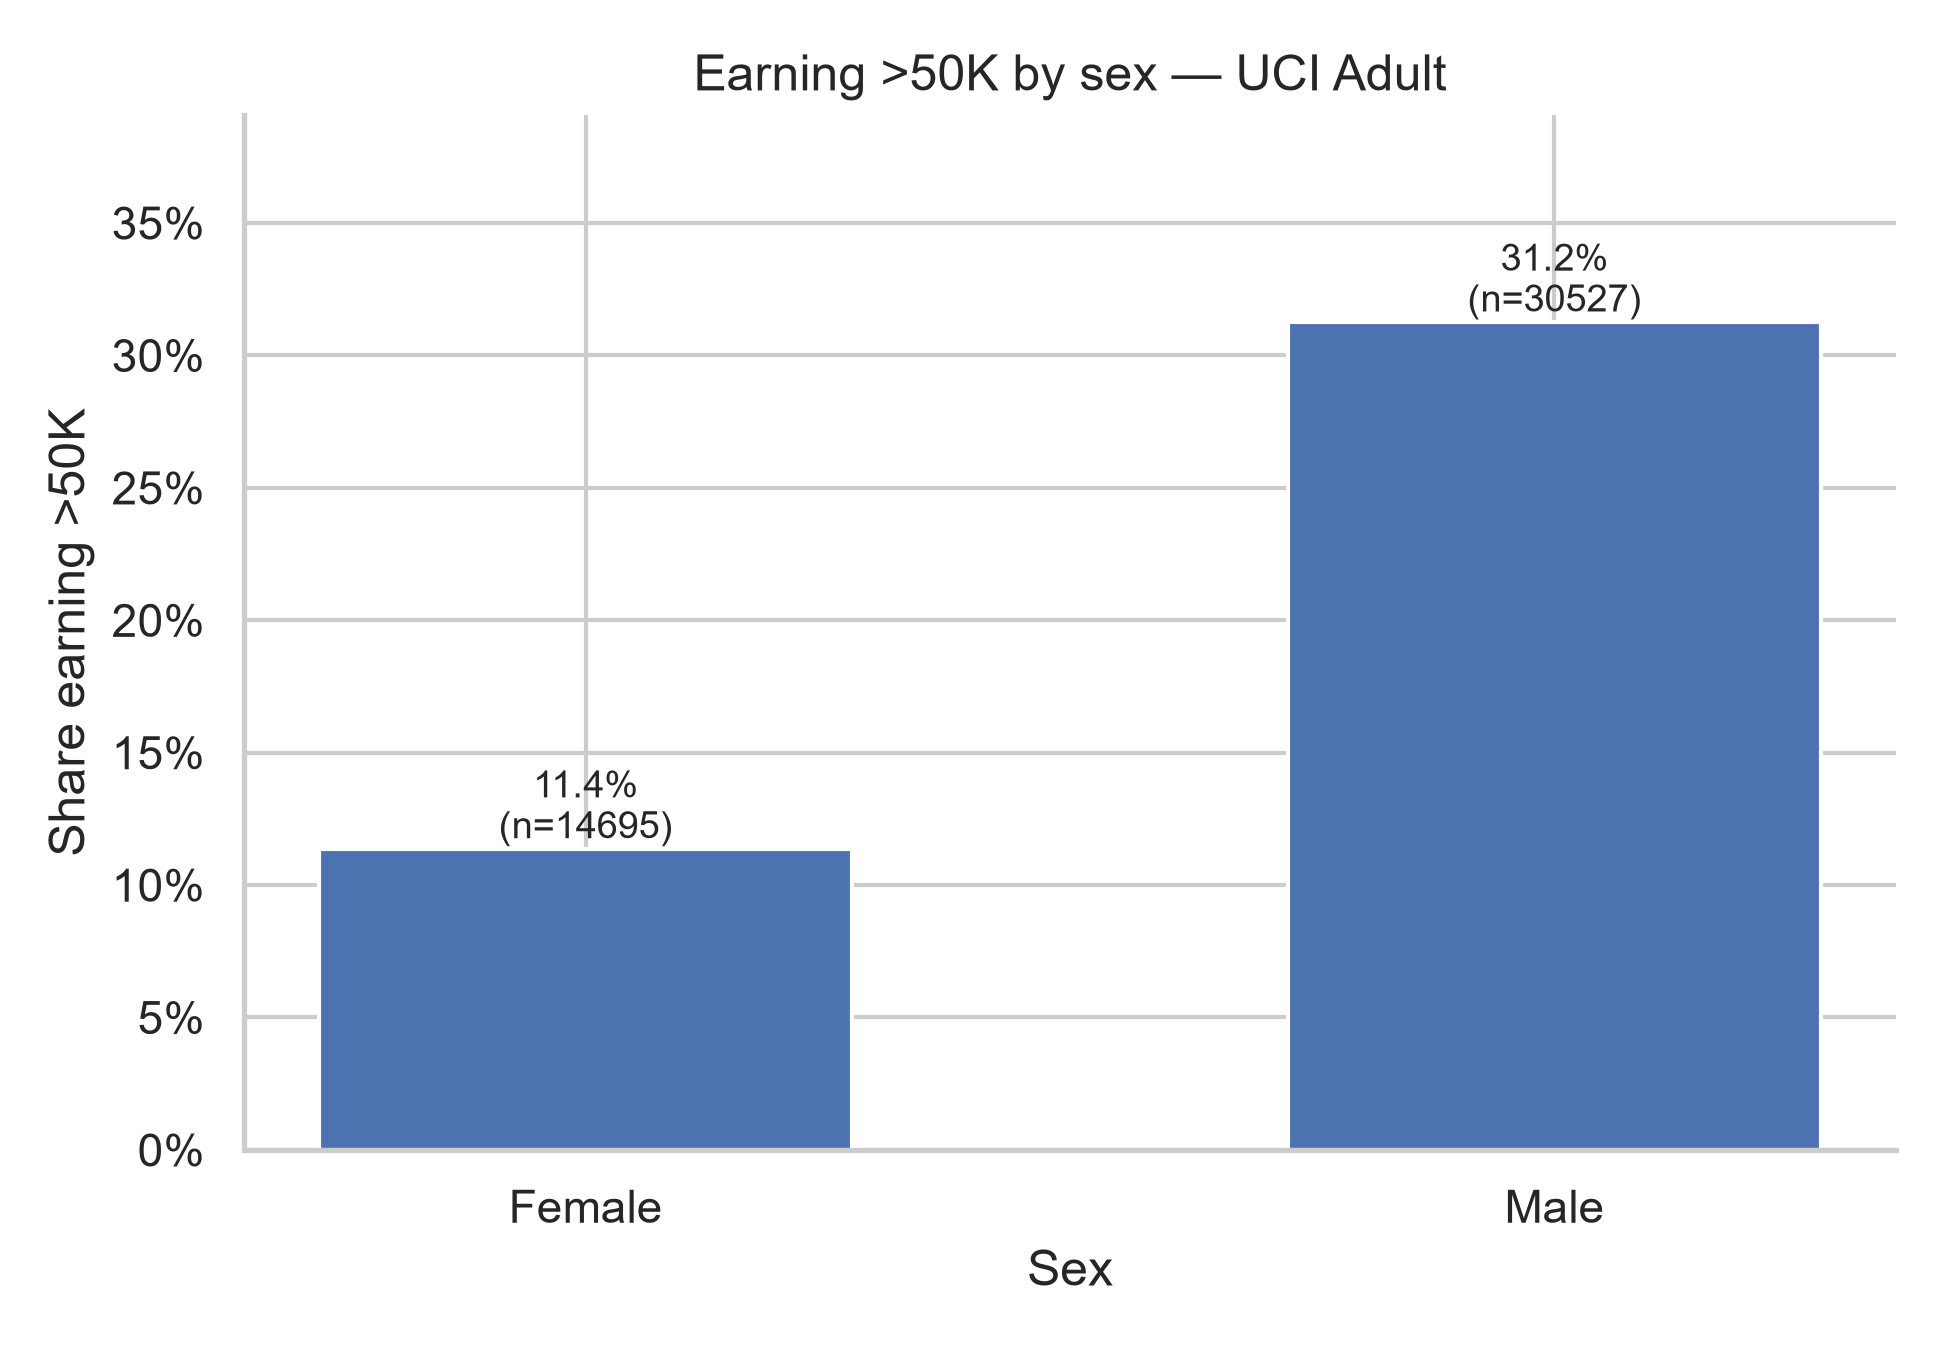

In [4]:
eda = pd.read_csv(RESULTS / "eda_sex_income.csv")
display(eda.round(4))
display(Image(filename=FIGURES / "fig1_outcome_by_sex.png", width=700))

## 2. Models, protocol and cost

`src/train.py` fits four estimators: logistic regression and an MLP (64, 32)
inside a `StandardScaler` pipeline, a 200-tree random forest and
200-estimator XGBoost. Each is trained for seeds 0-4 **on the same split** -
the data split is loaded once with seed 42 and never varies, so the loop seed
only changes the model's `random_state`.

Every fit and every inference runs under a codecarbon `EmissionsTracker`,
recorded separately in grams of CO2eq. Per-seed rows stay in memory only; the
saved tables are means and standard deviations over the five seeds.

In [5]:
models = pd.read_csv(RESULTS / "model_summary.csv")   # mean/std over 5 seeds
runs = pd.read_csv(RESULTS / "model_runs.csv")        # one row per seed

display(
    models[
        ["dataset", "model", "accuracy_mean", "accuracy_std",
         "f1_mean", "f1_std", "roc_auc_mean", "roc_auc_std"]
    ].round(4)
)
n_groups = runs.groupby(["dataset", "model"]).ngroups
print(f"{len(runs)} seed rows = {n_groups} dataset/model combinations x 5 seeds")

,dataset,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,adult,logreg,0.8421,0.0000,0.6467,0.0000,0.9022,0.0000
1,adult,random_forest,0.8372,0.0010,0.6527,0.0022,0.8875,0.0004
2,adult,xgboost,0.8623,0.0000,0.7005,0.0000,0.9229,0.0000
3,adult,mlp,0.8242,0.0031,0.6367,0.0067,0.8701,0.0018
4,german_credit,logreg,0.7400,0.0000,0.8194,0.0000,0.7758,0.0000
5,german_credit,random_forest,0.7493,0.0064,0.8362,0.0049,0.7620,0.0066
6,german_credit,xgboost,0.7333,0.0000,0.8174,0.0000,0.7287,0.0000
7,german_credit,mlp,0.6980,0.0128,0.7857,0.0114,0.7138,0.0101


40 seed rows = 8 dataset/model combinations x 5 seeds


**Baselines.** Accuracy is read against the majority-class classifier for the same split,
and the audit-group sizes show how noisy the per-group metrics are.

In [6]:
# Majority-class baseline and audit-group sizes (results/baselines.csv)
baselines = pd.read_csv(RESULTS / "baselines.csv")
display(baselines.round(4))
acc = baselines.drop_duplicates("dataset").set_index("dataset")
print("majority accuracy:", {k: round(v, 4) for k, v in acc.majority_accuracy.items()})

,dataset,group,n_train,n_test,positive_rate,majority_class,majority_accuracy,group_n_test,group_share_of_test,group_positive_rate
0,adult,Female,31655,13567,0.2478,0,0.7522,4427,0.3263,0.1195
1,adult,Male,31655,13567,0.2478,0,0.7522,9140,0.6737,0.3100
2,german_credit,25+,700,300,0.7000,1,0.7000,253,0.8433,0.7273
3,german_credit,under25,700,300,0.7000,1,0.7000,47,0.1567,0.5532


majority accuracy: {'adult': 0.7522, 'german_credit': 0.7}


## 3. Fairness of the unmitigated models

`src/fairness.py` refits the same models and scores them with fairlearn:

- **demographic parity difference** - largest gap in selection rate between groups (0 = equal);
- **demographic parity ratio** - smaller rate over larger rate; the *four-fifths rule* treats **>= 0.8** as acceptable;
- **equalized odds difference** - largest gap in TPR or FPR between groups (0 = equal).

Per-group accuracy and selection rate come from a fairlearn `MetricFrame` and
are stored long-format, one row per group: `Female`/`Male` on Adult and
`25+`/`under25` on German Credit.

In [7]:
fair_cols = [
    "dataset", "model",
    "demographic_parity_difference_mean", "demographic_parity_difference_std",
    "equalized_odds_difference_mean", "equalized_odds_difference_std",
    "demographic_parity_ratio_mean", "demographic_parity_ratio_std",
]
display(models[fair_cols].round(4))

ratio = models.pivot(index="model", columns="dataset",
                     values="demographic_parity_ratio_mean").round(4)
display(ratio)
display((ratio >= 0.8).rename(columns=lambda d: f"passes four-fifths: {d}"))

,dataset,model,demographic_parity_difference_mean,demographic_parity_difference_std,equalized_odds_difference_mean,equalized_odds_difference_std,demographic_parity_ratio_mean,demographic_parity_ratio_std
0,adult,logreg,0.1713,0.0000,0.0929,0.0000,0.3279,0.0000
1,adult,random_forest,0.1864,0.0014,0.0914,0.0018,0.3385,0.0032
2,adult,xgboost,0.1755,0.0000,0.0713,0.0000,0.3482,0.0000
3,adult,mlp,0.1775,0.0115,0.0930,0.0139,0.3963,0.0390
4,german_credit,logreg,0.0954,0.0000,0.1279,0.0000,0.8737,0.0000
5,german_credit,random_forest,0.0767,0.0387,0.1109,0.0426,0.9088,0.0466
6,german_credit,xgboost,0.1443,0.0000,0.2266,0.0000,0.8156,0.0000
7,german_credit,mlp,0.1557,0.0562,0.1746,0.0730,0.7882,0.0756


dataset,adult,german_credit
model,,
logreg,0.3279,0.8737
mlp,0.3963,0.7882
random_forest,0.3385,0.9088
xgboost,0.3482,0.8156


dataset,passes four-fifths: adult,passes four-fifths: german_credit
model,,
logreg,False,True
mlp,False,False
random_forest,False,True
xgboost,False,True


,dataset,model,group,accuracy,selection_rate
0,adult,logreg,Female,0.9176,0.0836
1,adult,logreg,Male,0.8056,0.2549
2,adult,mlp,Female,0.9015,0.1166
3,adult,mlp,Male,0.7867,0.2941
4,adult,random_forest,Female,0.9162,0.0954
5,adult,random_forest,Male,0.7989,0.2818
6,adult,xgboost,Female,0.9277,0.0937
7,adult,xgboost,Male,0.8306,0.2693
8,german_credit,logreg,25+,0.7668,0.7549
9,german_credit,logreg,under25,0.5957,0.6596


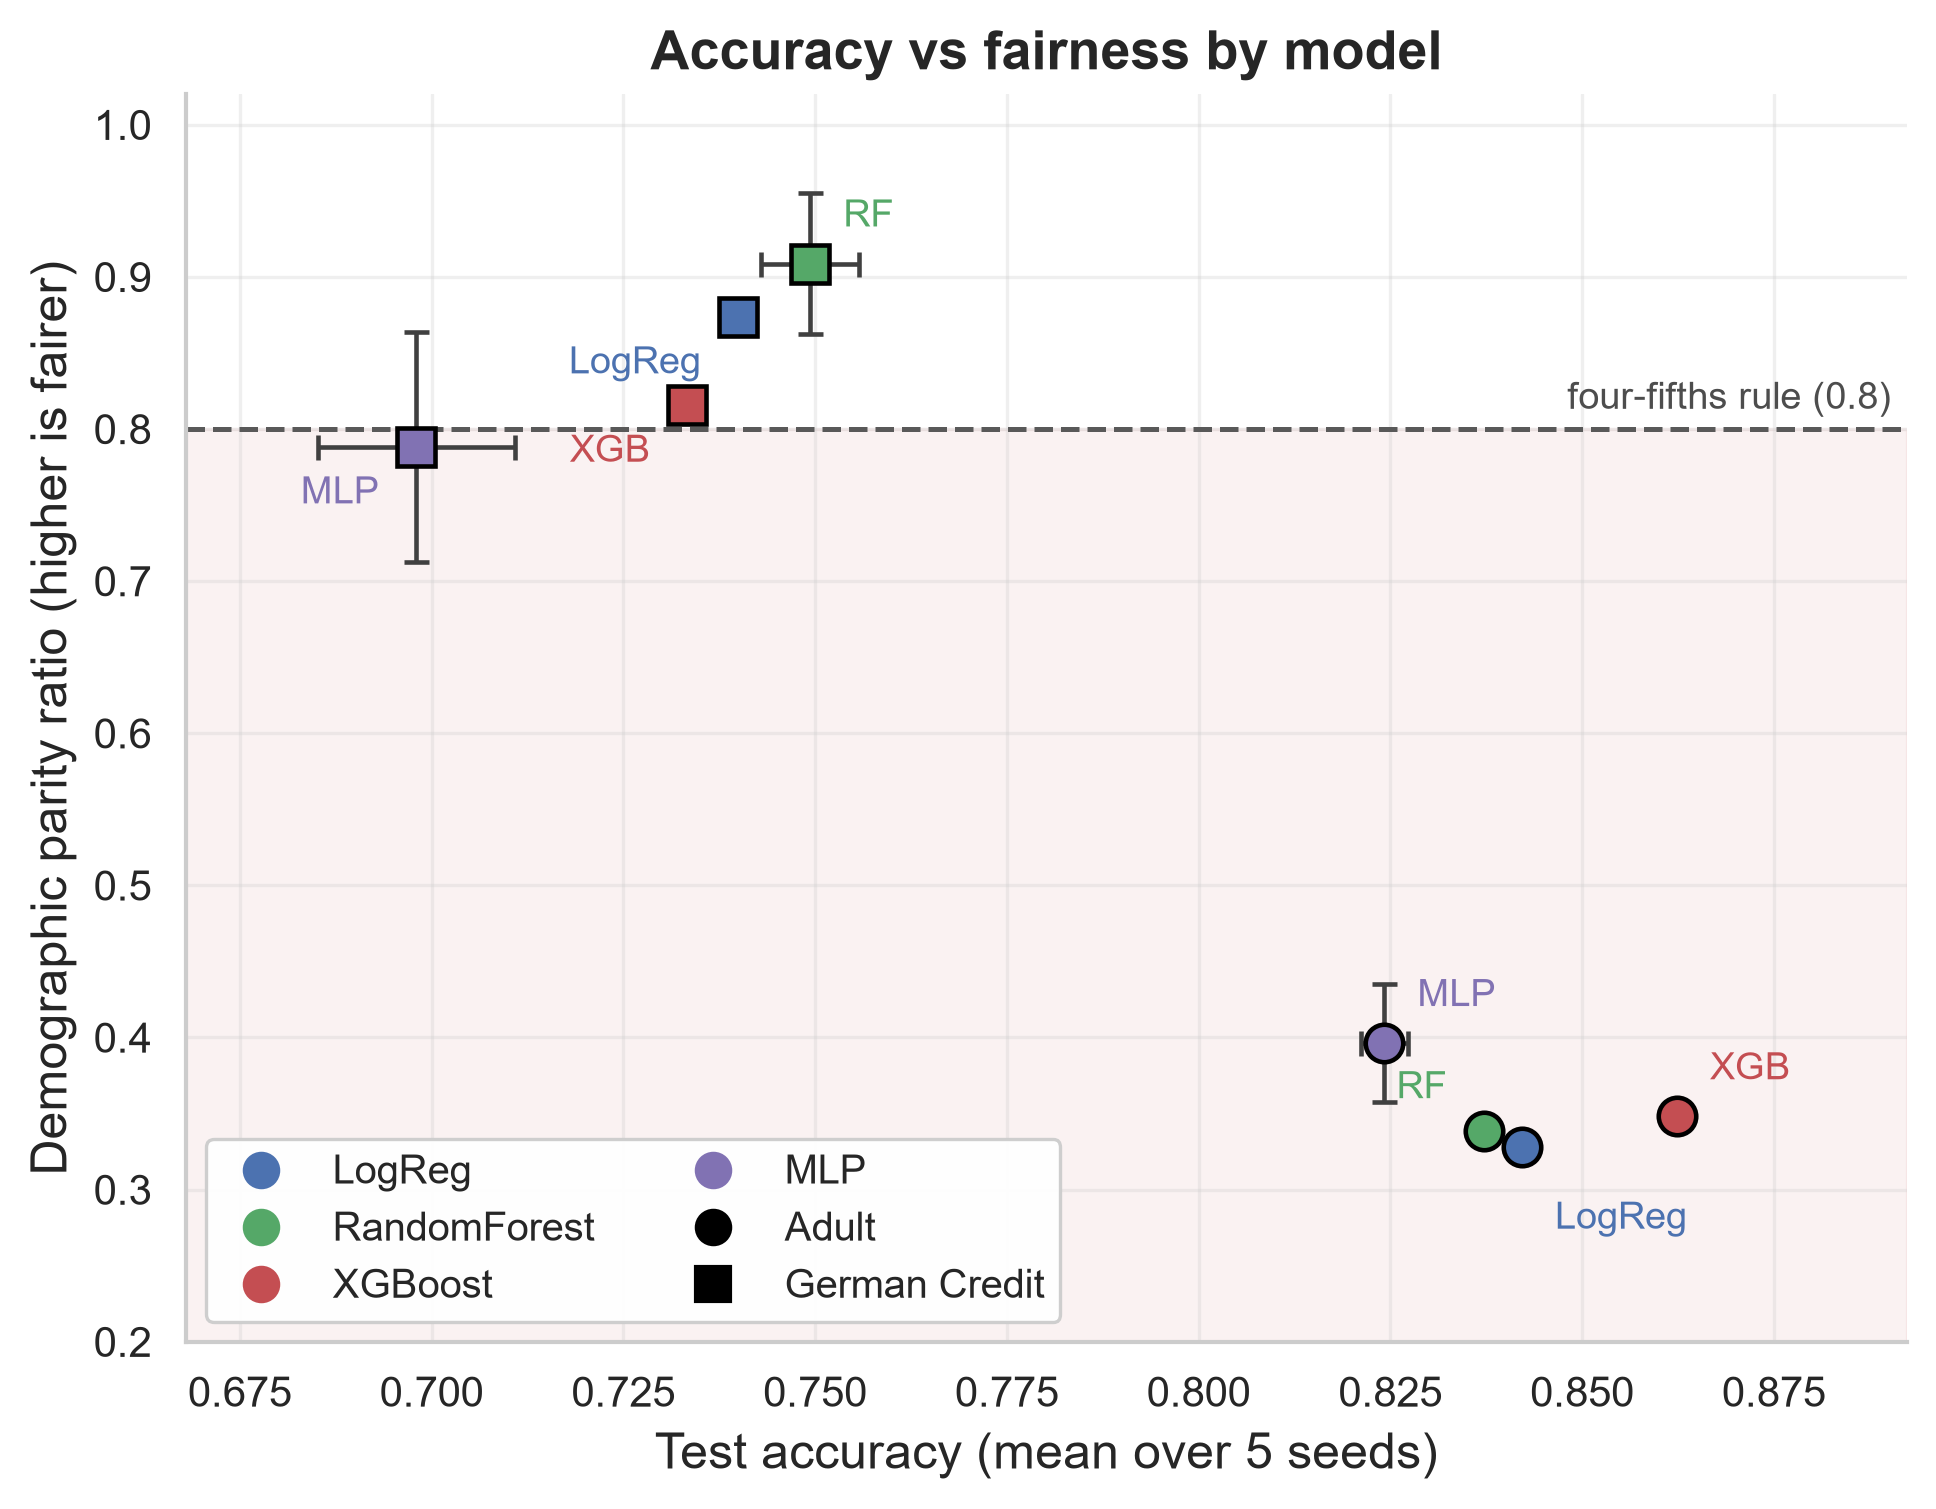

In [8]:
groups = pd.read_csv(RESULTS / "per_group_accuracy.csv")

per_group = (
    groups.groupby(["dataset", "model", "group"])[["accuracy", "selection_rate"]]
    .mean()
    .reset_index()
)
display(per_group.round(4))
display(Image(filename=FIGURES / "fig2_accuracy_vs_fairness.png", width=700))

## 4. Mitigation

`src/mitigation.py` applies three strategies and scores each model before and
after:

| method | strategy |
|---|---|
| `threshold_optimizer` | fairlearn `ThresholdOptimizer`, equalized-odds constraint, applied to XGBoost |
| `exponentiated_gradient` | fairlearn `ExponentiatedGradient` with `DemographicParity`, on logistic regression |
| `reweighing` | Kamiran-Calders reweighing passed to XGBoost as `sample_weight` |

Threshold optimisation and reweighing share one unmitigated XGBoost baseline;
exponentiated gradient starts from logistic regression, so the three arrows do
not share a starting point. Moving left is the goal, but a large drop in
accuracy is the price.

,dataset,method,accuracy_before_mean,accuracy_after_mean,demographic_parity_difference_before_mean,demographic_parity_difference_after_mean,demographic_parity_ratio_before_mean,demographic_parity_ratio_after_mean
0,adult,threshold_optimizer,0.8623,0.8513,0.1755,0.1197,0.3482,0.5318
1,adult,exponentiated_gradient,0.8421,0.8270,0.1713,0.0006,0.3279,0.9961
2,adult,reweighing,0.8623,0.8603,0.1755,0.1096,0.3482,0.5371
3,german_credit,threshold_optimizer,0.7333,0.7367,0.1443,0.1404,0.8156,0.8197
4,german_credit,exponentiated_gradient,0.7400,0.7507,0.0954,0.0068,0.8737,0.9913
5,german_credit,reweighing,0.7333,0.7267,0.1443,0.1033,0.8156,0.8646


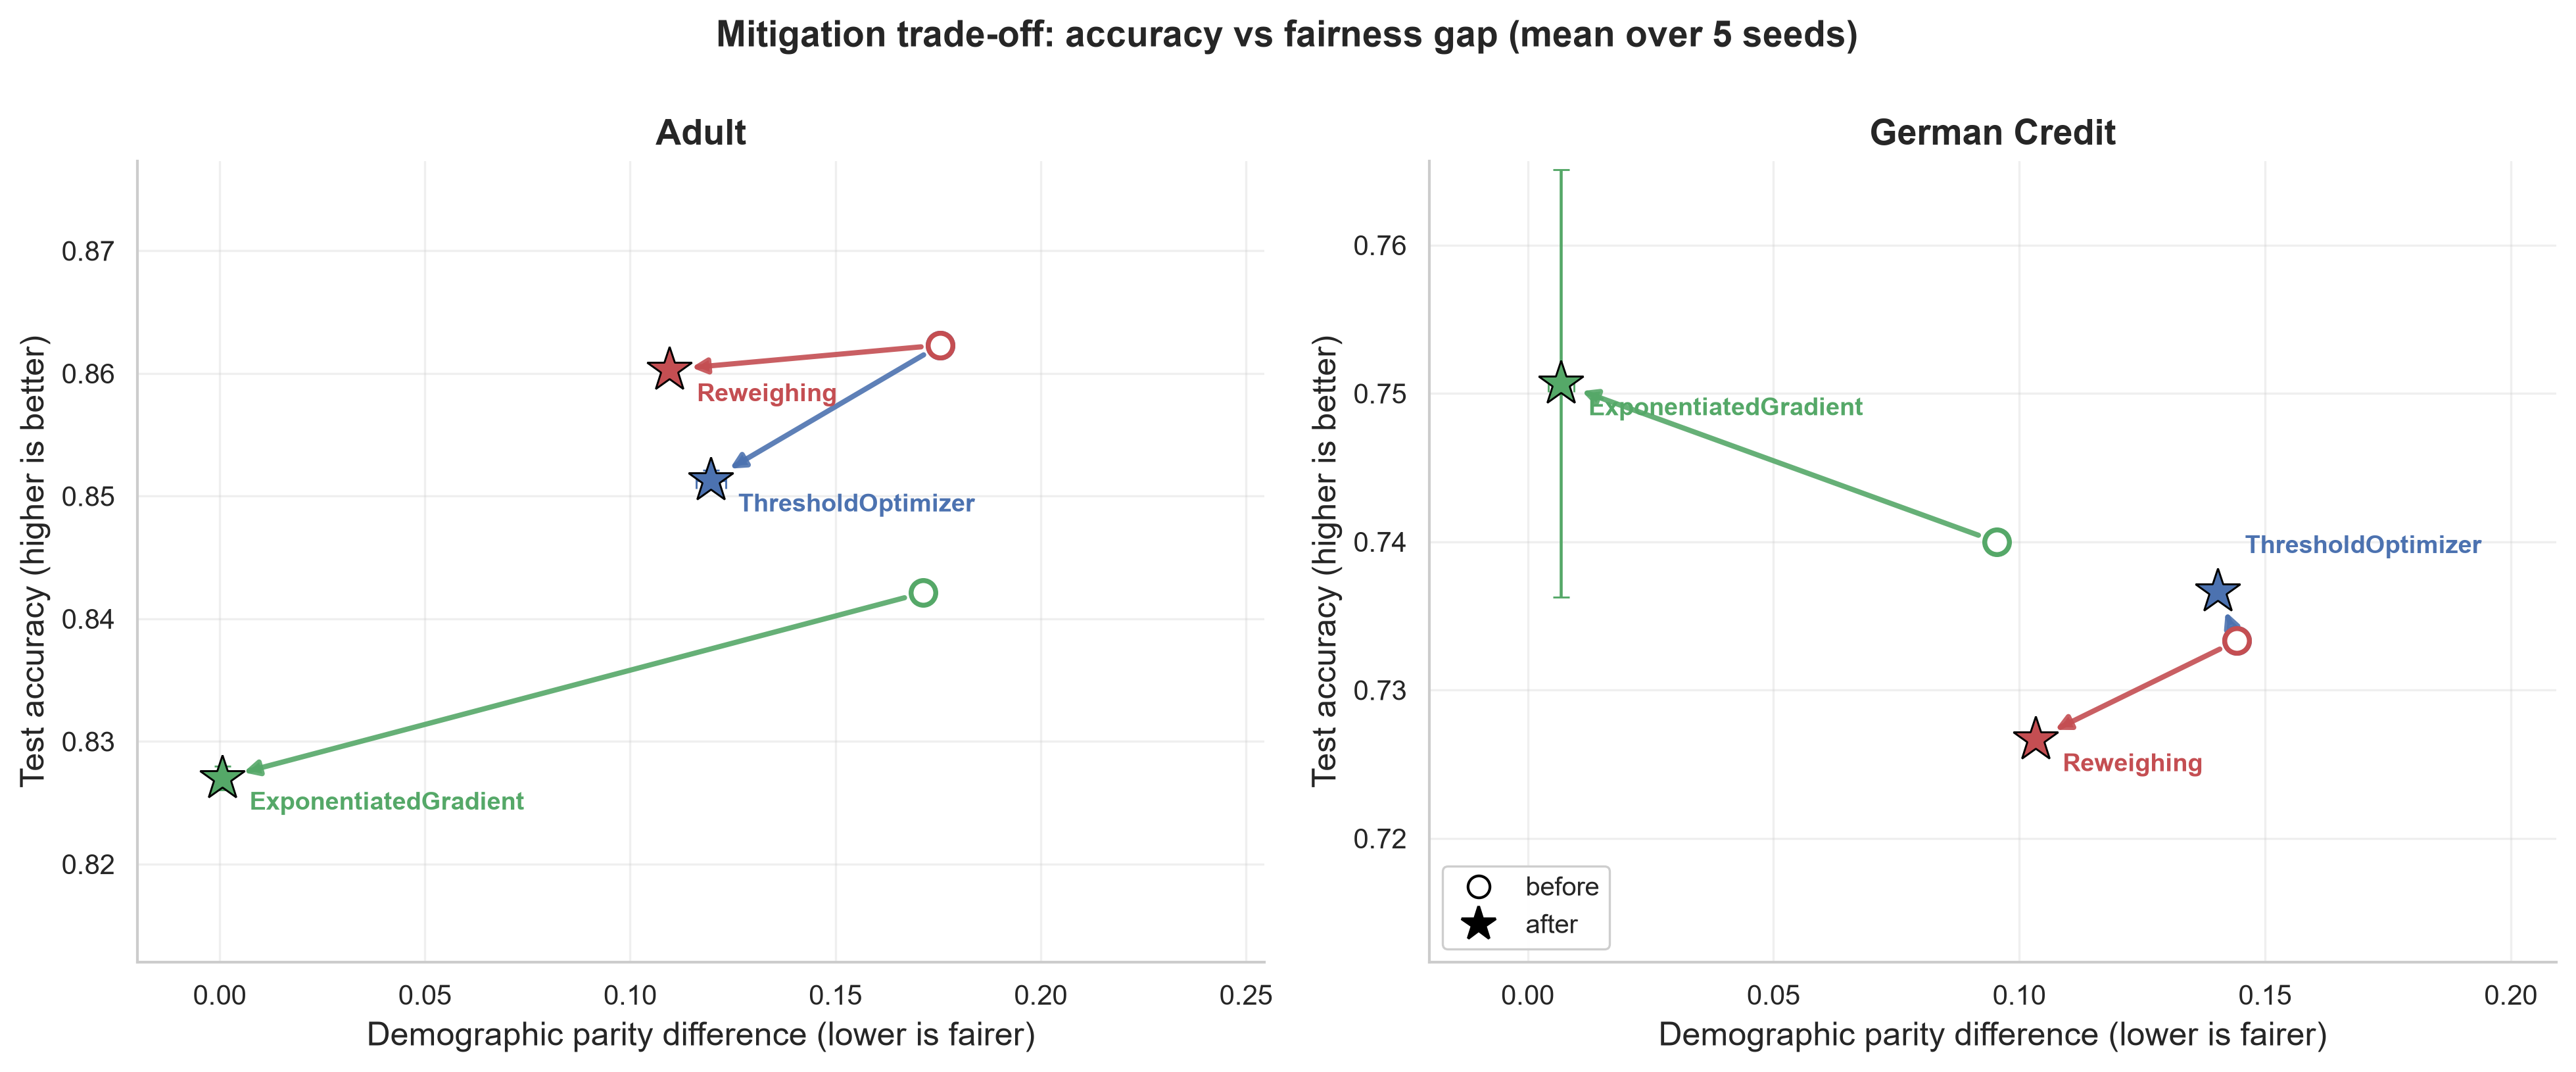

In [9]:
mit = pd.read_csv(RESULTS / "mitigation_summary.csv")
mit_view = mit[
    ["dataset", "method",
     "accuracy_before_mean", "accuracy_after_mean",
     "demographic_parity_difference_before_mean",
     "demographic_parity_difference_after_mean",
     "demographic_parity_ratio_before_mean",
     "demographic_parity_ratio_after_mean"]
]
display(mit_view.round(4))
display(Image(filename=FIGURES / "fig3_mitigation_tradeoff.png", width=960))

## 5. Carbon cost

`train_co2_g` and `inference_co2_g` are grams of CO2eq for the fitting phase
and for scoring the test set, averaged over the five seeds. The two phases are
an order of magnitude apart, and the datasets two more, so fig. 4 uses a
logarithmic axis. `train_share` below is the fraction of a model's footprint
that comes from fitting.

,dataset,model,train_co2_g_mean,train_co2_g_std,inference_co2_g_mean,inference_co2_g_std,train_seconds_mean,inference_seconds_mean,train_share
0,adult,logreg,0.001085,0.000530,0.000005,0.000004,0.423075,0.034313,0.995358
1,adult,random_forest,0.015869,0.009188,0.002156,0.001532,6.869956,0.926452,0.880414
2,adult,xgboost,0.005796,0.001519,0.000438,0.000133,2.082515,0.145639,0.929766
3,adult,mlp,0.264805,0.015325,0.000065,0.000085,105.684351,0.050943,0.999755
4,german_credit,logreg,0.000005,0.000004,0.000005,0.000004,0.018005,0.005500,0.512114
5,german_credit,random_forest,0.001291,0.000744,0.000461,0.000257,0.675969,0.233351,0.736674
6,german_credit,xgboost,0.001189,0.000678,0.000004,0.000002,0.573014,0.019272,0.996839
7,german_credit,mlp,0.002698,0.001686,0.000003,0.000003,1.345165,0.006708,0.998746


,dataset,model,train_co2_g_mean,inference_co2_g_mean,train_share
0,adult,logreg,0.0011,0.0000,0.9954
1,adult,random_forest,0.0159,0.0022,0.8804
2,adult,xgboost,0.0058,0.0004,0.9298
3,adult,mlp,0.2648,0.0001,0.9998
4,german_credit,logreg,0.0000,0.0000,0.5121
5,german_credit,random_forest,0.0013,0.0005,0.7367
6,german_credit,xgboost,0.0012,0.0000,0.9968
7,german_credit,mlp,0.0027,0.0000,0.9987


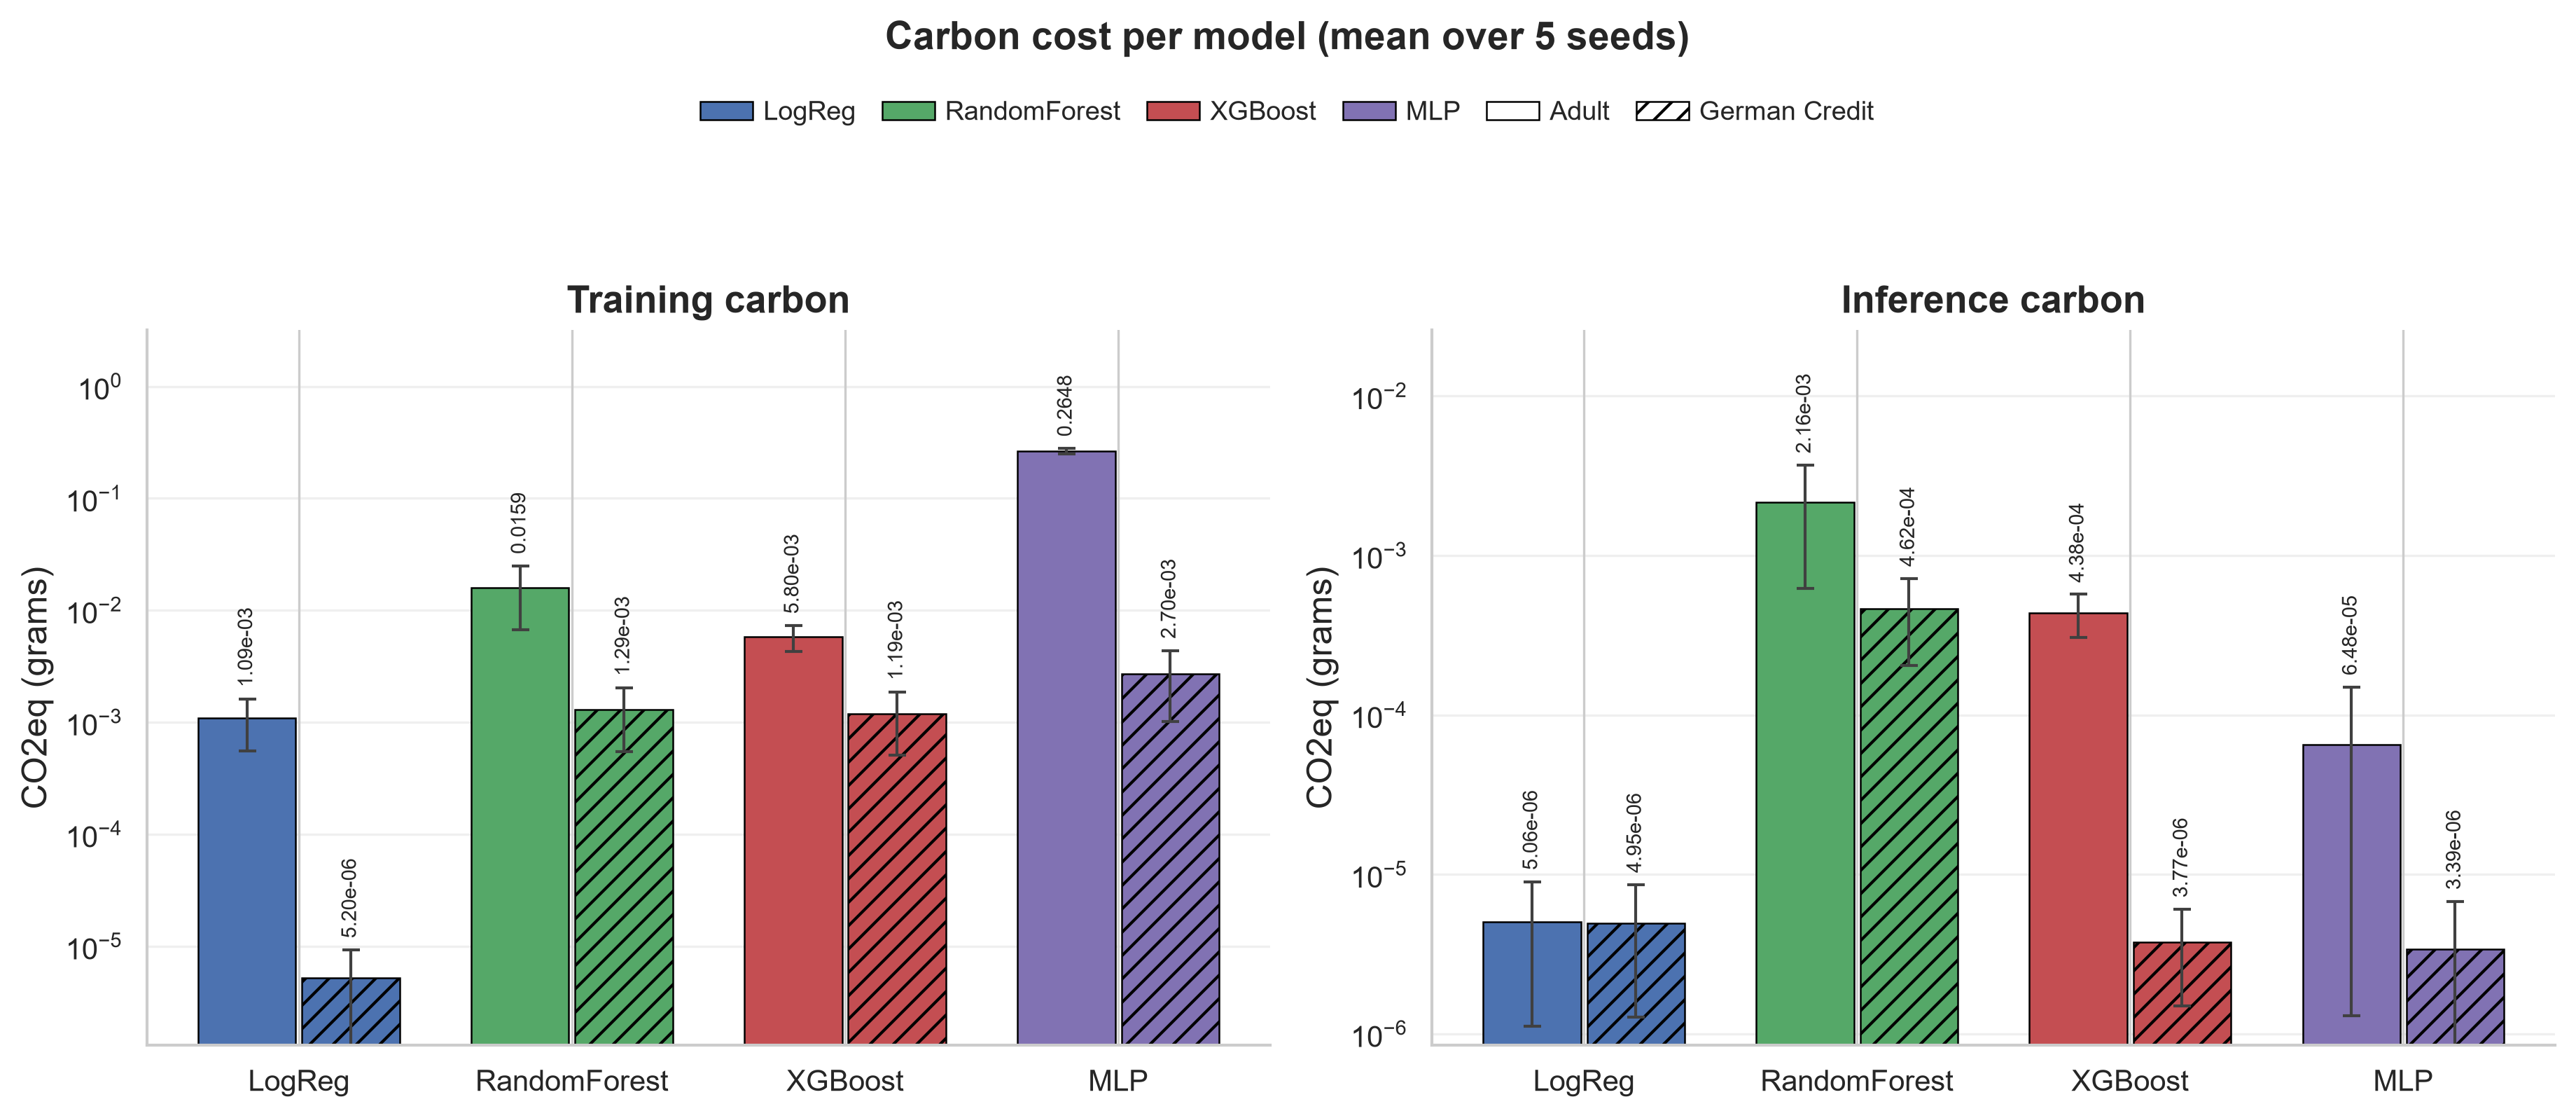

In [10]:
carbon = models[
    ["dataset", "model",
     "train_co2_g_mean", "train_co2_g_std",
     "inference_co2_g_mean", "inference_co2_g_std",
     "train_seconds_mean", "inference_seconds_mean"]
].copy()
carbon["train_share"] = (
    carbon.train_co2_g_mean
    / (carbon.train_co2_g_mean + carbon.inference_co2_g_mean)
)
display(carbon.round(8))
display(
    carbon[["dataset", "model", "train_co2_g_mean", "inference_co2_g_mean",
            "train_share"]].round(4)
)
display(Image(filename=FIGURES / "fig4_carbon_per_model.png", width=960))

## 6. Accuracy per gram of CO2eq

Dividing accuracy by training grams ranks the models by carbon efficiency.
Fig. 6 plots accuracy against training CO2eq on a log axis - the **top-left
corner is best** - and labels every point with its accuracy-per-gram ratio.

,dataset,model,accuracy_mean,train_co2_g_mean,accuracy_per_gram
0,german_credit,logreg,0.740000,5.2e-06,1.42e+05
1,adult,logreg,0.842117,0.00109,776
2,german_credit,xgboost,0.733333,0.00119,617
3,german_credit,random_forest,0.749333,0.00129,580
4,german_credit,mlp,0.698000,0.0027,259
5,adult,xgboost,0.862313,0.0058,149
6,adult,random_forest,0.837208,0.0159,52.8
7,adult,mlp,0.824176,0.265,3.11


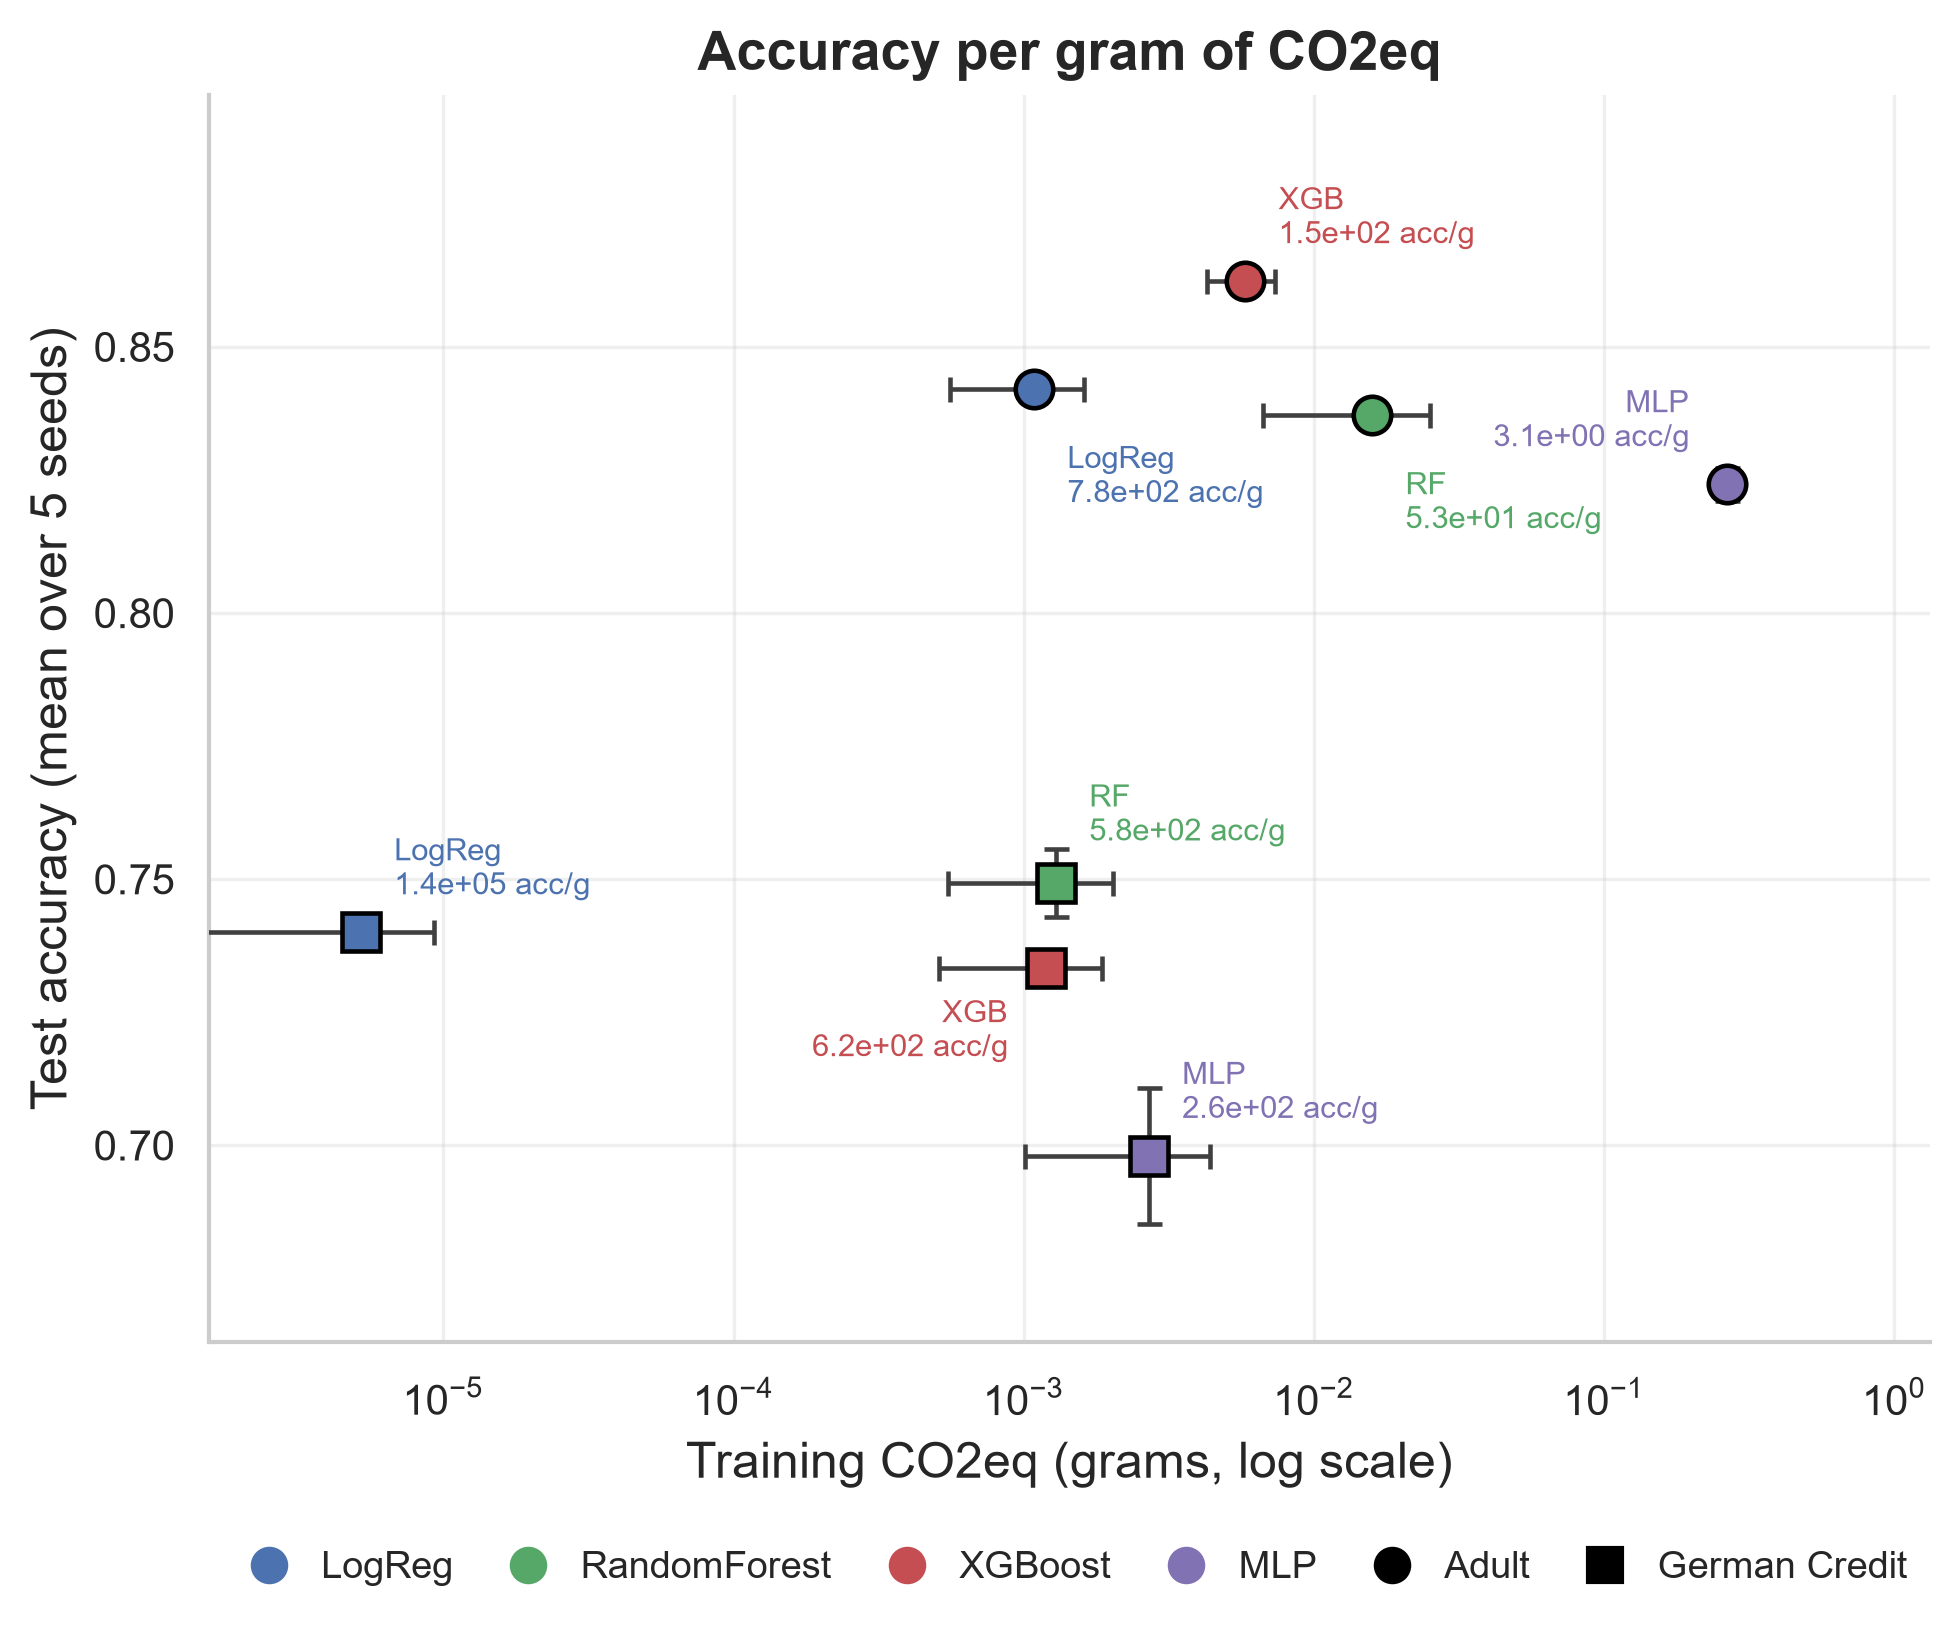

In [11]:
eff = models[["dataset", "model", "accuracy_mean", "train_co2_g_mean"]].copy()
eff["accuracy_per_gram"] = eff.accuracy_mean / eff.train_co2_g_mean
eff = eff.sort_values("accuracy_per_gram", ascending=False).reset_index(drop=True)
for column in ["train_co2_g_mean", "accuracy_per_gram"]:
    eff[column] = eff[column].map(lambda v: f"{v:.3g}")
display(eff)
display(Image(filename=FIGURES / "fig6_accuracy_per_gram_co2.png", width=700))

## 7. Explanations: which features decide, and do they leak sex?

`src/explain.py` fits the shared seed-42 XGBoost baseline on Adult, explains a
fixed 1000-row slice of the test set with SHAP, and ranks features by mean
|SHAP|. Each of the top 10 features is then correlated with the audit
attribute: a large `abs_correlation` means the model has an indirect path back
to the attribute that was removed from the feature list.

,dataset,mean_abs_shap,feature,mean_male,mean_female,mean_diff_male_minus_female,correlation_with_sex,abs_correlation
0,adult,1.2565,marital-status_Married-civ-spouse,0.6184,0.1570,0.4614,0.4336,0.4336
1,adult,0.3915,hours-per-week,42.6943,36.7628,5.9315,0.2324,0.2324
2,adult,0.0997,occupation_Other-service,0.0701,0.1805,-0.1104,-0.1680,0.1680
3,adult,0.1238,relationship_Own-child,0.1217,0.1995,-0.0778,-0.1030,0.1030
4,adult,0.8016,age,39.2608,37.1068,2.1540,0.0768,0.0768
5,adult,0.2144,capital-loss,102.1687,60.7215,41.4472,0.0482,0.0482
6,adult,0.1400,occupation_Prof-specialty,0.1201,0.1527,-0.0326,-0.0453,0.0453
7,adult,0.5872,capital-gain,1282.3937,601.4454,680.9482,0.0432,0.0432
8,adult,0.1423,occupation_Exec-managerial,0.1394,0.1138,0.0255,0.0355,0.0355
9,adult,0.4970,education-num,10.0915,10.1157,-0.0242,-0.0045,0.0045


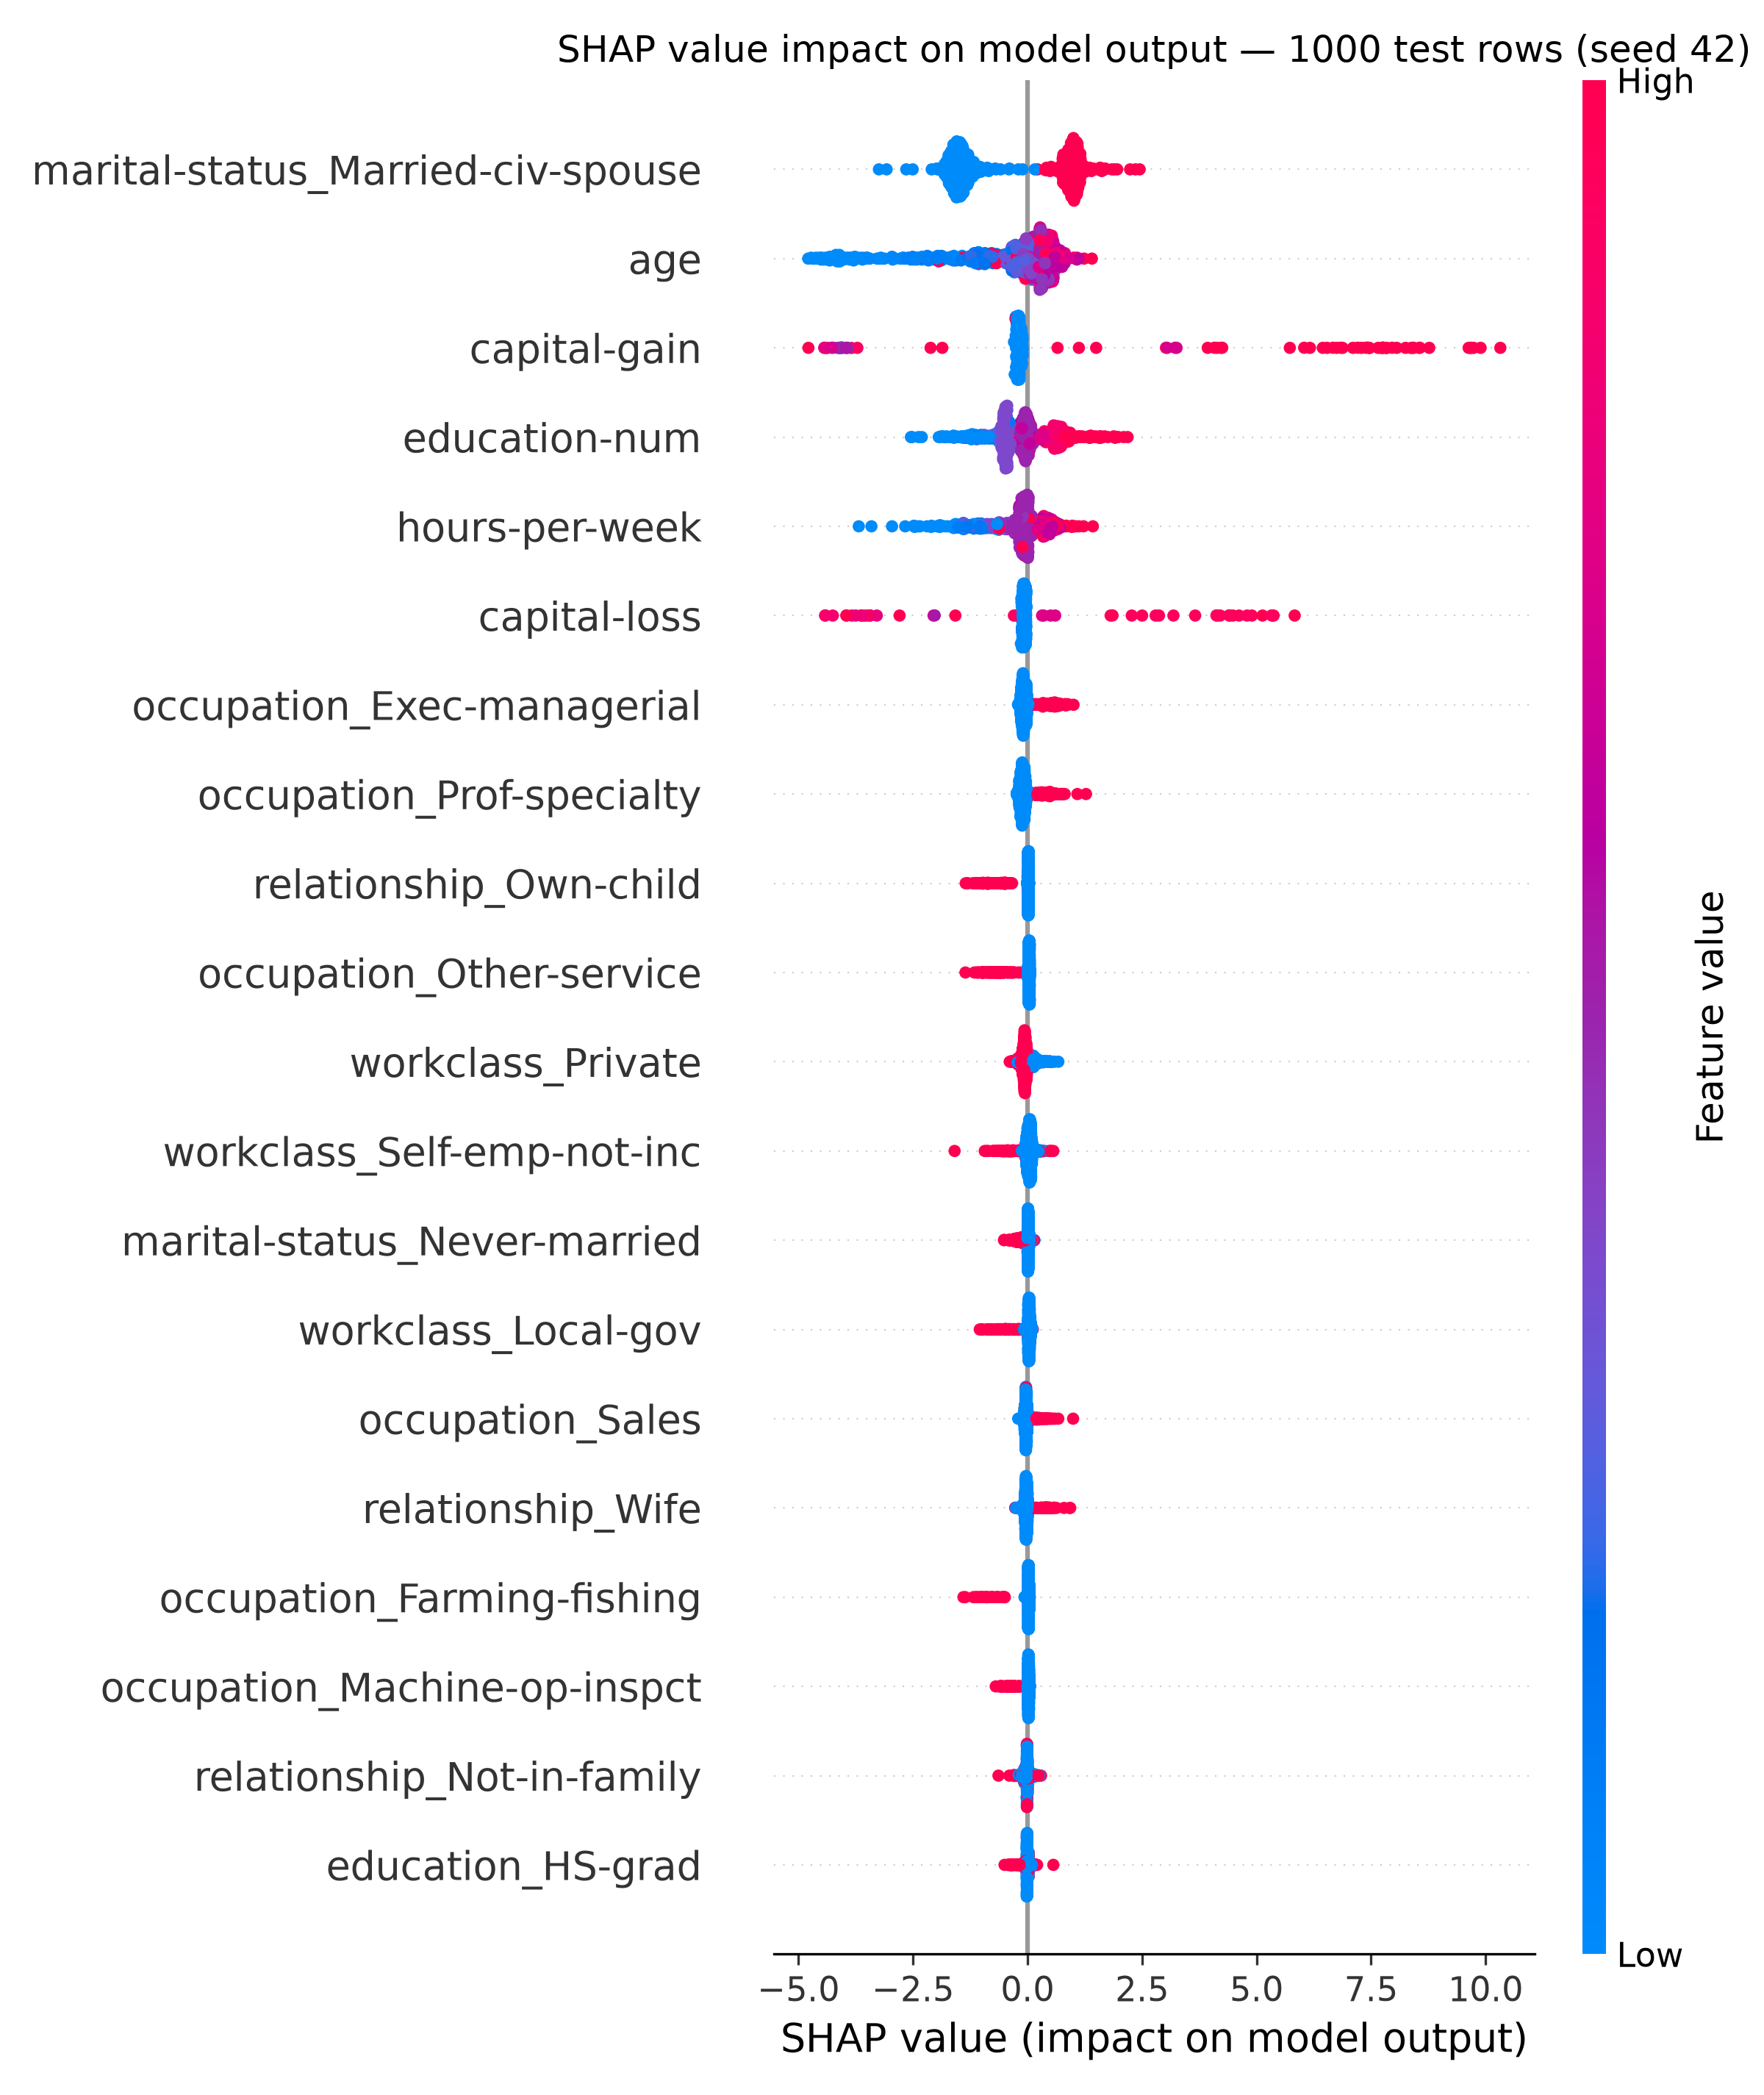

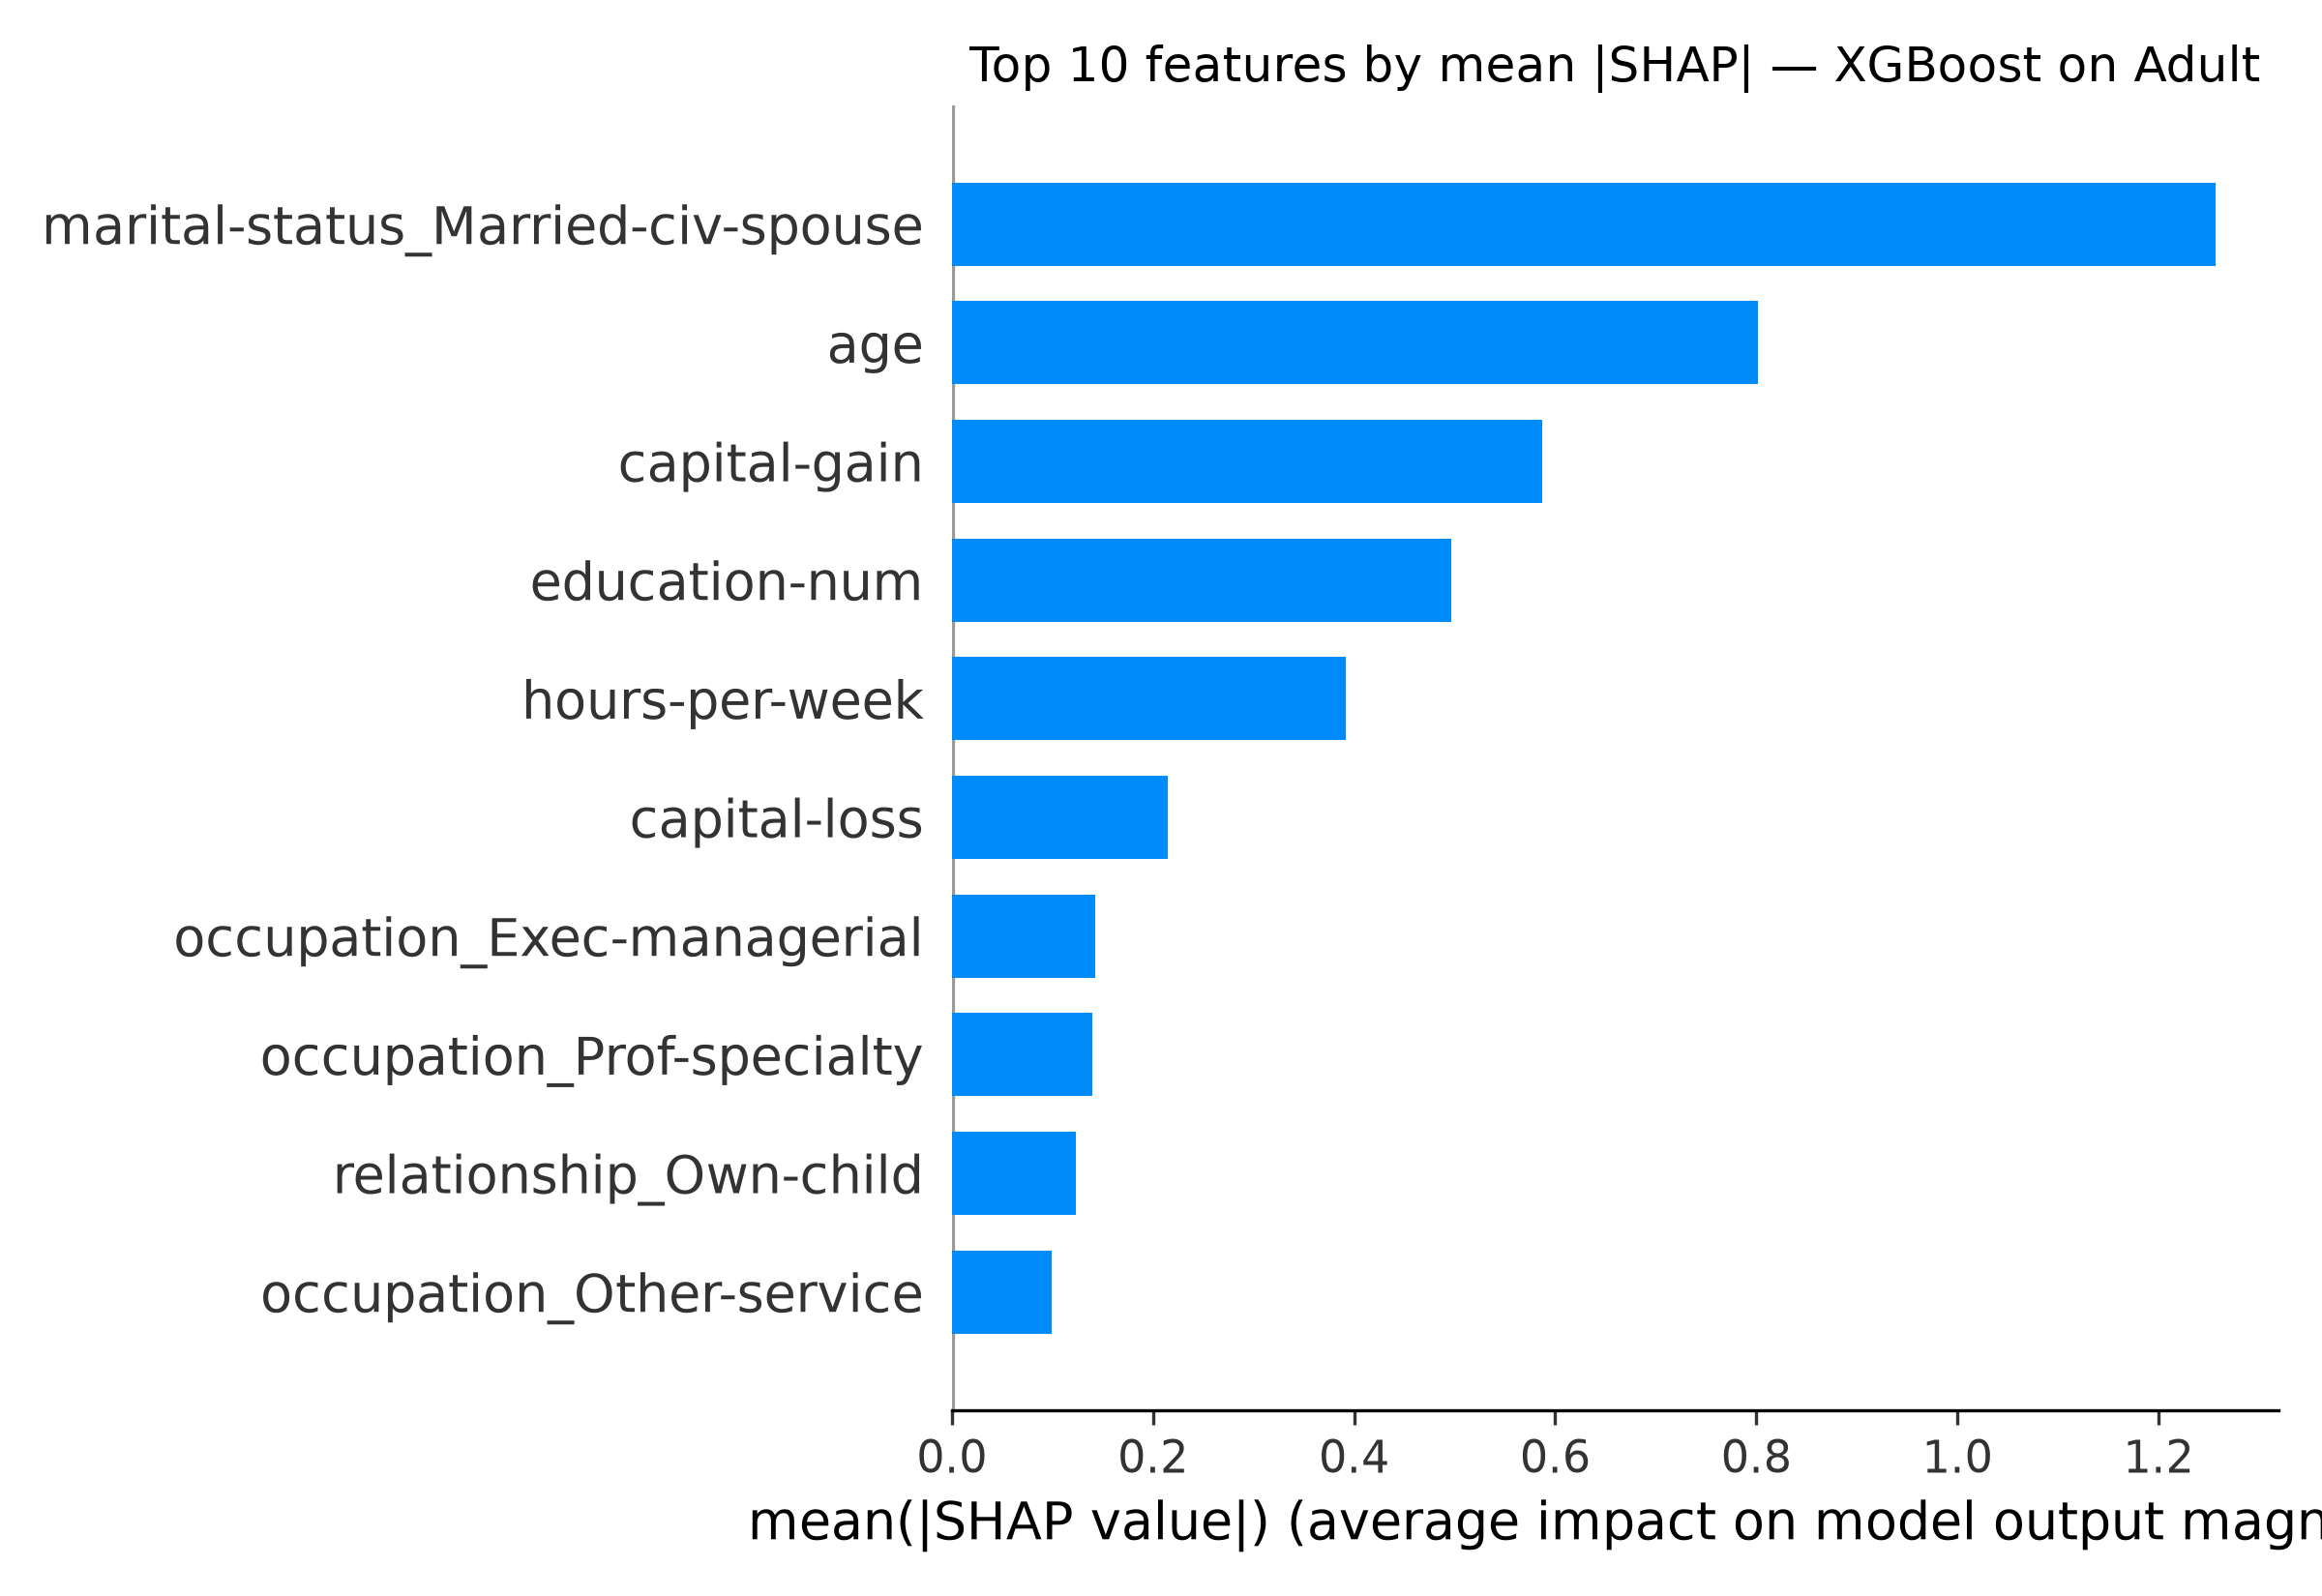

In [12]:
proxy = pd.read_csv(RESULTS / "proxy_features.csv")
display(proxy.round(4))
display(Image(filename=FIGURES / "fig5_shap_summary.png", width=700))
display(Image(filename=FIGURES / "fig5b_shap_top10_bar.png", width=700))

## 8. Replication on German Credit

German Credit is registered in `src/data.py` exactly like Adult, so the same
stages cover it - but it is far smaller, and the project records that caveat
wherever the dataset is announced:

In [13]:
print(SMALL_SAMPLE_WARNING, "\n")

german = models[models.dataset == "german_credit"]
display(
    german[
        ["model", "accuracy_mean", "accuracy_std",
         "demographic_parity_difference_mean",
         "equalized_odds_difference_mean",
         "demographic_parity_ratio_mean"]
    ].round(4)
)

german_mit = mit[mit.dataset == "german_credit"]
display(
    german_mit[
        ["method", "accuracy_before_mean", "accuracy_after_mean",
         "demographic_parity_ratio_before_mean",
         "demographic_parity_ratio_after_mean"]
    ].round(4)
)

# Age-group comparison: under25 is the small group the warning is about.
pg = groups[groups.dataset == "german_credit"]
display(pg.groupby(["model", "group"])[["accuracy", "selection_rate"]].mean().round(4))

German Credit has only 1000 rows. The 70/30 split leaves ~700 train and ~300 test rows, so per-group fairness metrics, per-group accuracy and CO2 readings are all noisy: a handful of rows can shift a selection rate by several points, and the 'under25' group may hold only a few dozen rows. 



,model,accuracy_mean,accuracy_std,demographic_parity_difference_mean,equalized_odds_difference_mean,demographic_parity_ratio_mean
4,logreg,0.7400,0.0000,0.0954,0.1279,0.8737
5,random_forest,0.7493,0.0064,0.0767,0.1109,0.9088
6,xgboost,0.7333,0.0000,0.1443,0.2266,0.8156
7,mlp,0.6980,0.0128,0.1557,0.1746,0.7882


,method,accuracy_before_mean,accuracy_after_mean,demographic_parity_ratio_before_mean,demographic_parity_ratio_after_mean
3,threshold_optimizer,0.7333,0.7367,0.8156,0.8197
4,exponentiated_gradient,0.7400,0.7507,0.8737,0.9913
5,reweighing,0.7333,0.7267,0.8156,0.8646


accuracy  selection_rate
model         group                            
logreg        25+        0.7668          0.7549
              under25    0.5957          0.6596
mlp           25+        0.7209          0.7344
              under25    0.5745          0.5787
random_forest 25+        0.7771          0.8427
              under25    0.6000          0.7660
xgboost       25+        0.7708          0.7826
              under25    0.5319          0.6383

## 9. What the audit shows

The numbers are printed below rather than quoted here, so nothing in this
notebook can drift away from `results/`:

- which model wins on accuracy, and on which dataset;
- how many of the eight model/dataset rows fail the four-fifths rule;
- which mitigation method leaves the smallest parity gap;
- which model has the largest training footprint.

In [14]:
# Everything below is computed from results/*.csv at run time.
best = models.loc[models.accuracy_mean.idxmax()]
worst = models.loc[models.demographic_parity_ratio_mean.idxmin()]
dirty = models.loc[models.train_co2_g_mean.idxmax()]
clean = mit.loc[mit.demographic_parity_difference_after_mean.idxmin()]
failing = models[models.demographic_parity_ratio_mean < 0.8]

print(f"best accuracy              : {best.accuracy_mean:.4f}  "
      f"({best.dataset} / {best.model})")
print(f"worst parity ratio         : {worst.demographic_parity_ratio_mean:.4f}  "
      f"({worst.dataset} / {worst.model})")
print(f"fail four-fifths           : {len(failing)} of {len(models)} "
      "dataset/model rows")
print(f"largest training footprint : {dirty.train_co2_g_mean:.6f} g  "
      f"({dirty.dataset} / {dirty.model})")
print(f"smallest parity gap after mitigation : "
      f"{clean.demographic_parity_difference_after_mean:.4f}  "
      f"({clean.dataset} / {clean.method})")

display(
    models.groupby("dataset")[["accuracy_mean", "demographic_parity_ratio_mean"]]
    .mean()
    .round(4)
)

best accuracy              : 0.8623  (adult / xgboost)
worst parity ratio         : 0.3279  (adult / logreg)
fail four-fifths           : 5 of 8 dataset/model rows
largest training footprint : 0.264805 g  (adult / mlp)
smallest parity gap after mitigation : 0.0006  (adult / exponentiated_gradient)


,accuracy_mean,demographic_parity_ratio_mean
dataset,,
adult,0.8415,0.3527
german_credit,0.7302,0.8466


## Provenance

| output | written by | read by |
|---|---|---|
| `results/eda_sex_income.csv`, `figures/fig1_*` | `src/eda.py` | section 1 |
| `results/model_runs.csv`, `model_summary.csv` | `src/fairness.py` (supersedes `src/train.py`) | sections 2, 3, 5, 6, 8 |
| `results/per_group_accuracy.csv` | `src/fairness.py` | sections 3, 8 |
| `results/mitigation_runs.csv`, `mitigation_summary.csv` | `src/mitigation.py` | sections 4, 8 |
| `results/proxy_features.csv`, `figures/fig5_*` | `src/explain.py` | section 7 |
| `figures/fig2`, `fig3`, `fig4`, `fig6` | `src/figures.py` (from the CSVs alone) | sections 3-6 |

Tables are written one dataset at a time and merged by dataset, so an Adult
run and a German Credit run end in the same combined files. Re-running
`python run_all.py` regenerates every number above from scratch.